# Avance 3. Baseline


## Librerías y Carga de Datos

In [1]:
USE_PLOTLY = False

### Librerías

In [2]:
import sys
sys.path.append('../../')

In [3]:
import pandas as pd
import numpy as np
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# !pip install holidays
from src.utils import helpers as func
# !pip install prince
import prince as pr
import plotly.express as px

### Carga de Datos

In [4]:
# path = '../../data/processed/df_entidades_acum.parquet'
path = '../../data/processed/df_acumulado.parquet'
df = func.load_data(path)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Dimensiones del DataFrame: (573, 11)

Primeras filas del DataFrame:


,fecha,valor_acumulado,semana,rolling_mean,rolling_std,upper_bound,lower_bound,is_outlier,valor_acumulado_corregido,mes,año
0,2014-01-06,131.0,2,NaN,NaN,NaN,NaN,False,131.0,1,2014
1,2014-01-13,789.0,3,NaN,NaN,NaN,NaN,False,789.0,1,2014
2,2014-01-20,1722.0,4,880.666667,799.451270,1999.898445,-238.565112,False,1722.0,1,2014
3,2014-01-27,2745.0,5,1346.750000,1137.987807,2939.932930,-246.432930,False,2745.0,1,2014
4,2014-02-03,3896.0,6,2288.000000,1336.895658,4159.653921,416.346079,False,3896.0,2,2014


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573 entries, 0 to 572
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   fecha                      573 non-null    datetime64[ns]
 1   valor_acumulado            573 non-null    float64       
 2   semana                     573 non-null    UInt32        
 3   rolling_mean               571 non-null    float64       
 4   rolling_std                571 non-null    float64       
 5   upper_bound                571 non-null    float64       
 6   lower_bound                571 non-null    float64       
 7   is_outlier                 573 non-null    bool          
 8   valor_acumulado_corregido  573 non-null    float64       
 9   mes                        573 non-null    int32         
 10  año                        573 non-null    int32         
dtypes: UInt32(1), bool(1), datetime64[ns](1), float64(6), int32(2)
memory u

None

## Análisis de la Serie Temporal

### Serie Original

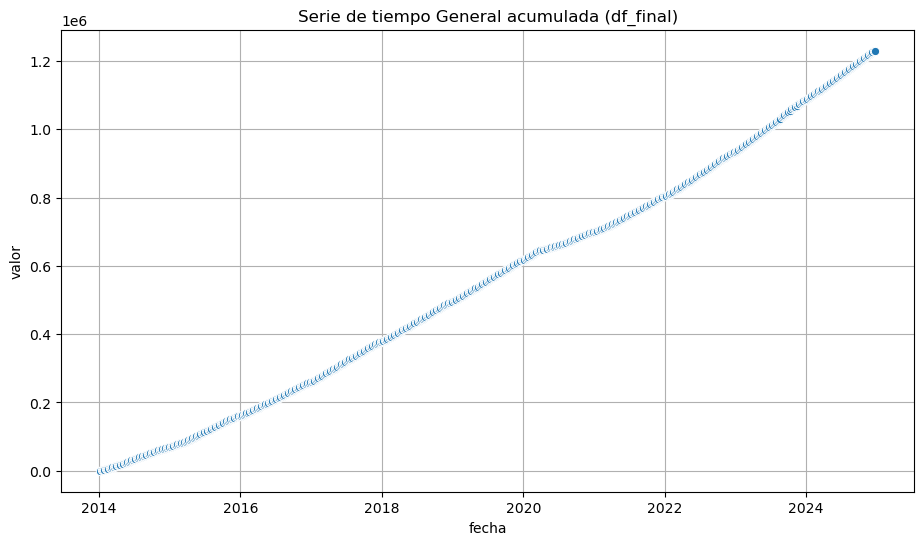

In [5]:
# Dataframe con las columnas necesarias para el análisis de series temporales
df_filtrado = df[['fecha', 'valor_acumulado_corregido']].copy()
df_filtrado.rename(columns={'valor_acumulado_corregido': 'valor'}, inplace=True)
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General acumulada (df_final)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_filtrado, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)


#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

In [6]:
ts_data = df_filtrado.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data.head())

# Mostrar información de la serie temporal
print("\nInformación de la serie temporal:")
ts_data.info()

Serie temporal preparada para descomposición:


fecha
2014-01-06     131.0
2014-01-13     789.0
2014-01-20    1722.0
2014-01-27    2745.0
2014-02-03    3896.0
Name: valor, dtype: float64


Información de la serie temporal:
<class 'pandas.core.series.Series'>
DatetimeIndex: 573 entries, 2014-01-06 to 2024-12-23
Series name: valor
Non-Null Count  Dtype  
--------------  -----  
573 non-null    float64
dtypes: float64(1)
memory usage: 9.0 KB


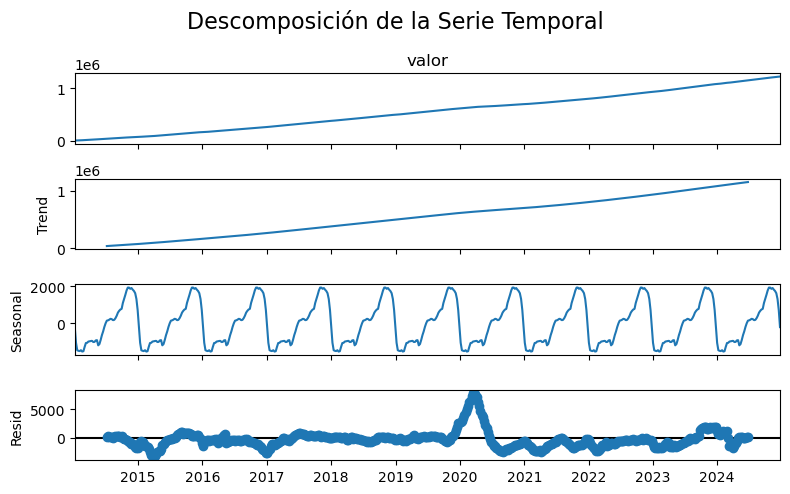

In [7]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

func.show_decomposition(ts_data, model='additive', figsize=(8, 5))

#### Pruebas de estacionaridad

##### Análisis de Resultados: Prueba ADF

In [8]:
estadistico_adf, p_value_adf, crit_val_adf = func.adf_test(ts_data)


Resultados de la Prueba ADF
╒═════════════════╤════════════════╤══════════════════════════╕
│ Métrica         │   Valor Prueba │   Nivel de Significancia │
╞═════════════════╪════════════════╪══════════════════════════╡
│ Estadístico ADF │        3.33816 │                 -2.86663 │
├─────────────────┼────────────────┼──────────────────────────┤
│ p-value         │        1       │                  0.05    │
╘═════════════════╧════════════════╧══════════════════════════╛


##### Análisis de Resultados: Prueba KPSS

In [9]:
estadistico_kpss, p_value_kpss, crit_val_kpss = func.kpss_test(ts_data)


Resultados de la Prueba KPSS
╒══════════════════╤════════════════╤══════════════════════════╕
│ Métrica          │   Valor Prueba │   Nivel de Significancia │
╞══════════════════╪════════════════╪══════════════════════════╡
│ Estadístico KPSS │        3.45345 │                    0.463 │
├──────────────────┼────────────────┼──────────────────────────┤
│ p-value          │        0.01    │                    0.05  │
╘══════════════════╧════════════════╧══════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\helpers.py:343: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c')


### Serie Transformada

#### Logaritmo

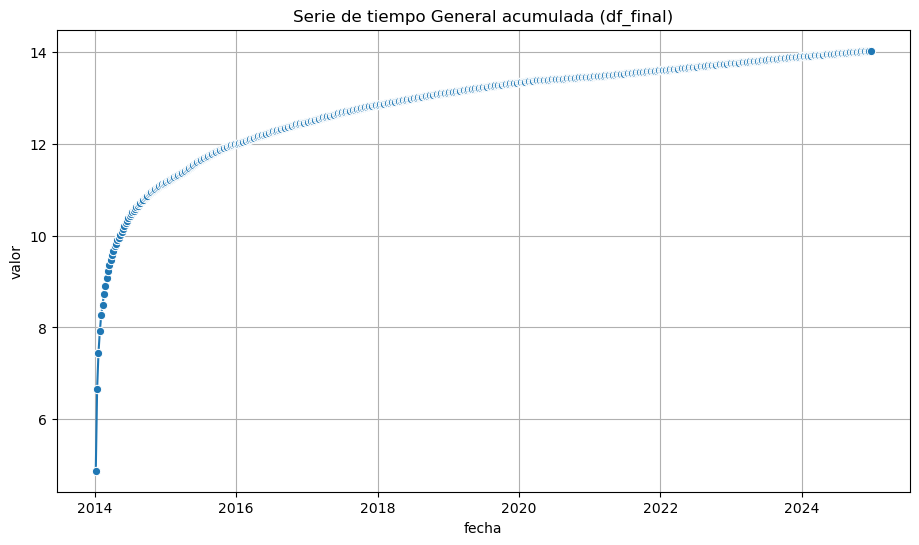

In [10]:
df_log = df_filtrado.copy()
df_log['valor'] = np.log1p(df_log['valor'])
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General acumulada (df_final)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_log, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

##### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

In [11]:
ts_data_log = df_log.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_log.head())

# Mostrar información de la serie temporal
print("\nInformación de la serie temporal:")
ts_data_log.info()

Serie temporal preparada para descomposición:


fecha
2014-01-06    4.882802
2014-01-13    6.672033
2014-01-20    7.451822
2014-01-27    7.917901
2014-02-03    8.267962
Name: valor, dtype: float64


Información de la serie temporal:
<class 'pandas.core.series.Series'>
DatetimeIndex: 573 entries, 2014-01-06 to 2024-12-23
Series name: valor
Non-Null Count  Dtype  
--------------  -----  
573 non-null    float64
dtypes: float64(1)
memory usage: 9.0 KB


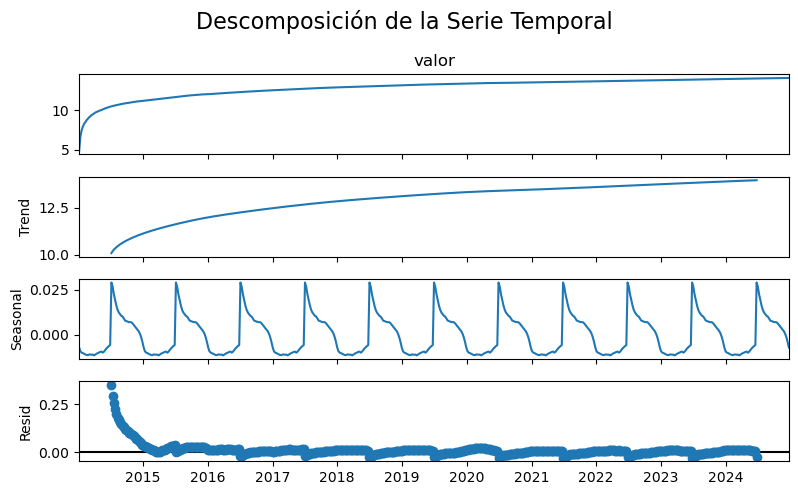

In [12]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
func.show_decomposition(ts_data_log, model='additive', figsize=(8, 5))

##### Pruebas de estacionaridad

###### Análisis de Resultados: Prueba ADF

In [13]:
estadistico_adf, p_value_adf, crit_val_adf = func.adf_test(ts_data_log)

Resultados de la Prueba ADF
╒═════════════════╤════════════════╤══════════════════════════╕
│ Métrica         │   Valor Prueba │   Nivel de Significancia │
╞═════════════════╪════════════════╪══════════════════════════╡
│ Estadístico ADF │   -4.58247     │                 -2.86678 │
├─────────────────┼────────────────┼──────────────────────────┤
│ p-value         │    0.000139127 │                  0.05    │
╘═════════════════╧════════════════╧══════════════════════════╛


###### Análisis de Resultados: Prueba KPSS

In [14]:
estadistico_kpss, p_value_kpss, crit_val_kpss = func.kpss_test(ts_data_log)


Resultados de la Prueba KPSS
╒══════════════════╤════════════════╤══════════════════════════╕
│ Métrica          │   Valor Prueba │   Nivel de Significancia │
╞══════════════════╪════════════════╪══════════════════════════╡
│ Estadístico KPSS │        2.98925 │                    0.463 │
├──────────────────┼────────────────┼──────────────────────────┤
│ p-value          │        0.01    │                    0.05  │
╘══════════════════╧════════════════╧══════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\helpers.py:343: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c')


### Box-Cox

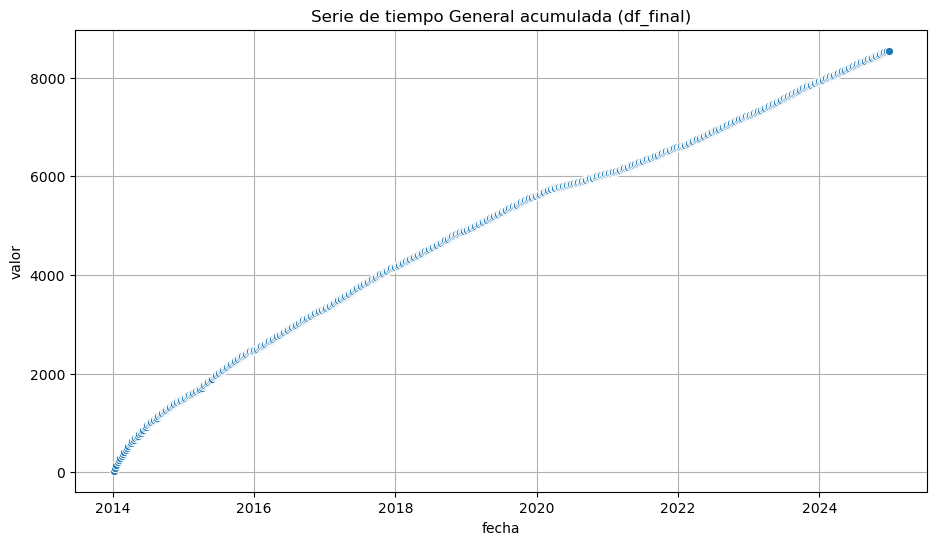

In [15]:
from scipy import stats
df_boxcox = df_filtrado.copy()
serie_transformada, lambda_optimo = stats.boxcox(df_boxcox['valor'])
df_boxcox['valor'] = serie_transformada

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General acumulada (df_final)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_boxcox, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

##### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

In [16]:
ts_data_boxcox = df_boxcox.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_boxcox.head())

# Mostrar información de la serie temporal
print("\nInformación de la serie temporal:")
ts_data_boxcox.info()

Serie temporal preparada para descomposición:


fecha
2014-01-06     30.484284
2014-01-13     94.484346
2014-01-20    153.148627
2014-01-27    204.117338
2014-02-03    253.152479
Name: valor, dtype: float64


Información de la serie temporal:
<class 'pandas.core.series.Series'>
DatetimeIndex: 573 entries, 2014-01-06 to 2024-12-23
Series name: valor
Non-Null Count  Dtype  
--------------  -----  
573 non-null    float64
dtypes: float64(1)
memory usage: 9.0 KB


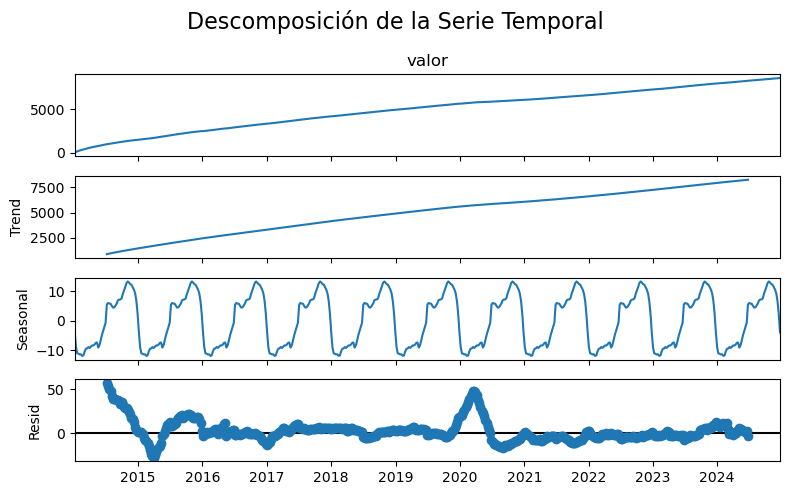

In [17]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
func.show_decomposition(ts_data_boxcox, model='additive', figsize=(8, 5))

##### Pruebas de estacionaridad

###### Análisis de Resultados: Prueba ADF

In [18]:
estadistico_adf, p_value_adf, crit_val_adf = func.adf_test(ts_data_boxcox)

Resultados de la Prueba ADF
╒═════════════════╤════════════════╤══════════════════════════╕
│ Métrica         │   Valor Prueba │   Nivel de Significancia │
╞═════════════════╪════════════════╪══════════════════════════╡
│ Estadístico ADF │     -2.84954   │                 -2.86671 │
├─────────────────┼────────────────┼──────────────────────────┤
│ p-value         │      0.0515382 │                  0.05    │
╘═════════════════╧════════════════╧══════════════════════════╛


###### Análisis de Resultados: Prueba KPSS

In [19]:
estadistico_kpss, p_value_kpss, crit_val_kpss = func.kpss_test(ts_data_boxcox)


Resultados de la Prueba KPSS
╒══════════════════╤════════════════╤══════════════════════════╕
│ Métrica          │   Valor Prueba │   Nivel de Significancia │
╞══════════════════╪════════════════╪══════════════════════════╡
│ Estadístico KPSS │        3.41899 │                    0.463 │
├──────────────────┼────────────────┼──────────────────────────┤
│ p-value          │        0.01    │                    0.05  │
╘══════════════════╧════════════════╧══════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\helpers.py:343: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c')


#### Logaritmo + Diff

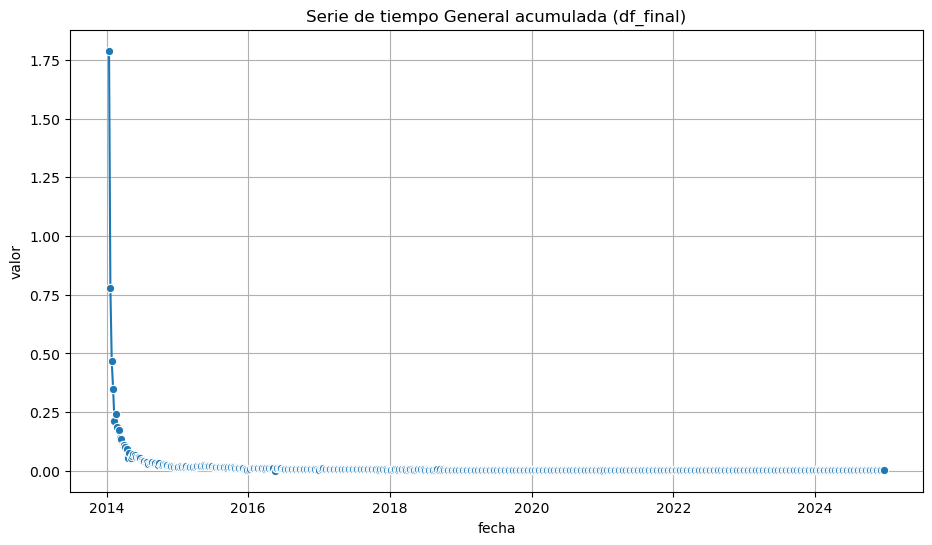

In [20]:
df_log_diff = df_log[['fecha','valor']].copy()
df_diff1 = df_log_diff.set_index('fecha').diff().dropna().reset_index()
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General acumulada (df_final)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_diff1, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

##### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

In [21]:
ts_data_log_diff = df_diff1.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_log_diff.head())

# Mostrar información de la serie temporal
print("\nInformación de la serie temporal:")
ts_data_log_diff.info()

Serie temporal preparada para descomposición:


fecha
2014-01-13    1.789231
2014-01-20    0.779789
2014-01-27    0.466078
2014-02-03    0.350062
2014-02-10    0.213396
Name: valor, dtype: float64


Información de la serie temporal:
<class 'pandas.core.series.Series'>
DatetimeIndex: 572 entries, 2014-01-13 to 2024-12-23
Series name: valor
Non-Null Count  Dtype  
--------------  -----  
572 non-null    float64
dtypes: float64(1)
memory usage: 8.9 KB


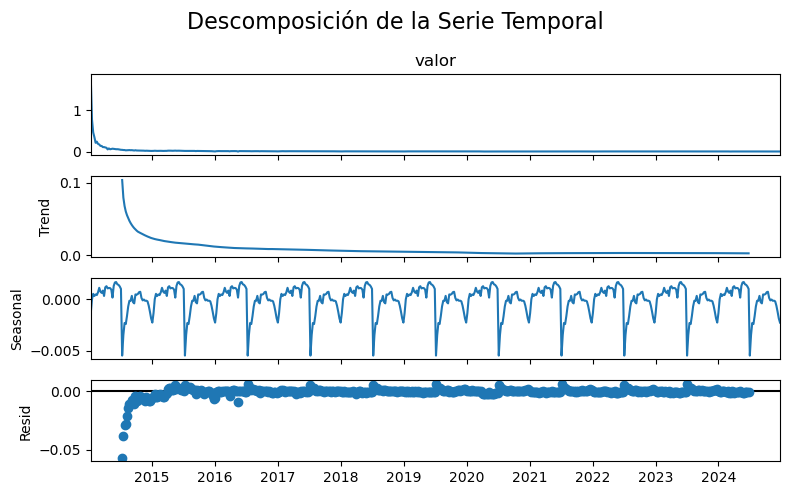

In [22]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
func.show_decomposition(ts_data_log_diff, model='additive', figsize=(8, 5))

##### Pruebas de estacionaridad

###### Análisis de Resultados: Prueba ADF

In [23]:
estadistico_adf, p_value_adf, crit_val_adf = func.adf_test(ts_data_log_diff)

Resultados de la Prueba ADF
╒═════════════════╤════════════════╤══════════════════════════╕
│ Métrica         │   Valor Prueba │   Nivel de Significancia │
╞═════════════════╪════════════════╪══════════════════════════╡
│ Estadístico ADF │   -4.74944     │                 -2.86678 │
├─────────────────┼────────────────┼──────────────────────────┤
│ p-value         │    6.78851e-05 │                  0.05    │
╘═════════════════╧════════════════╧══════════════════════════╛


###### Análisis de Resultados: Prueba KPSS

In [24]:
estadistico_kpss, p_value_kpss, crit_val_kpss = func.kpss_test(ts_data_log_diff)


Resultados de la Prueba KPSS
╒══════════════════╤════════════════╤══════════════════════════╕
│ Métrica          │   Valor Prueba │   Nivel de Significancia │
╞══════════════════╪════════════════╪══════════════════════════╡
│ Estadístico KPSS │       0.839578 │                    0.463 │
├──────────────────┼────────────────┼──────────────────────────┤
│ p-value          │       0.01     │                    0.05  │
╘══════════════════╧════════════════╧══════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\helpers.py:343: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c')


## Exponential Smoothing

In [25]:
from statsmodels.tsa.holtwinters import Holt

In [26]:
# índice temporal
data = df_log.sort_values('fecha')
data = data.set_index('fecha')
train_size = int(len(data) * 0.8)


train, test = data.iloc[:train_size], data.iloc[train_size:]
print(f'Tamaño del conjunto de entrenamiento: {len(train)}')
print(f'Tamaño del conjunto de prueba: {len(test)}')

Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


In [27]:
display(train.head(), test.head())

,valor
fecha,
2014-01-06,4.882802
2014-01-13,6.672033
2014-01-20,7.451822
2014-01-27,7.917901
2014-02-03,8.267962


,valor
fecha,
2022-10-17,13.719841
2022-10-24,13.723063
2022-10-31,13.726221
2022-11-07,13.728647
2022-11-14,13.731743


In [28]:
# model_double = Holt(data)
model_double = Holt(train)
model_double_fit = model_double.fit()

d:\conda_env\depression-analysis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


In [29]:
forecast_double = model_double_fit.forecast(115)
print(forecast_double)

2022-10-17    13.719795
2022-10-24    13.723012
2022-10-31    13.726228
2022-11-07    13.729445
2022-11-14    13.732662
                ...    
2024-11-25    14.073628
2024-12-02    14.076844
2024-12-09    14.080061
2024-12-16    14.083278
2024-12-23    14.086494
Freq: W-MON, Length: 115, dtype: float64


In [30]:
df_original = data.copy().reset_index()
df_original['valor_original'] = np.expm1(df_original['valor'])


df_ajustado = pd.DataFrame(model_double_fit.fittedvalues, columns=['valor']).reset_index()
df_ajustado['valor_original'] = np.expm1(df_ajustado['valor'])
df_pronostico = pd.DataFrame(forecast_double, columns=['valor']).reset_index()
df_pronostico.rename(columns={'index': 'fecha'}, inplace=True)
df_pronostico['valor_original'] = np.expm1(df_pronostico['valor'])

In [31]:
import plotly.graph_objects as go

y = 'valor'
mode = 'lines'
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_original['fecha'], y=df_original[y], mode=mode, name='Datos Originales'))
fig.add_trace(go.Scatter(x=df_ajustado['fecha'], y=df_ajustado[y], mode=mode, name='Datos Ajustados'))
fig.add_trace(go.Scatter(x=df_pronostico['fecha'], y=df_pronostico[y], mode=mode, name='Pronóstico'))

fig.update_layout(
    title='Double Exponential Smoothing log-transform',
    xaxis_title='Fecha',
    yaxis_title='Casos',
    legend_title='Series'
)
fig.show()

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluar_modelo(y_pred, y_true):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

print("Evaluación del modelo en el conjunto de entrenamiento:")
mae, rmse = evaluar_modelo(df_ajustado['valor'], train['valor'])
print(f'MAE: {mae}, RMSE: {rmse}')

print("\nEvaluación del modelo en el conjunto de prueba:")
mae, rmse = evaluar_modelo(df_pronostico['valor'], test['valor'])
print(f'MAE: {mae}, RMSE: {rmse}')

Evaluación del modelo en el conjunto de entrenamiento:
MAE: 0.01012003303753865, RMSE: 0.0950314140397704

Evaluación del modelo en el conjunto de prueba:
MAE: 0.02566402597794466, RMSE: 0.031200025961713847


In [33]:
forecast_double2 = model_double_fit.forecast(200)
df_pronostico2 = pd.DataFrame(forecast_double2, columns=['valor']).reset_index()
df_pronostico2.rename(columns={'index': 'fecha'}, inplace=True)
df_pronostico2['valor_original'] = np.expm1(df_pronostico2['valor'])

In [34]:
y = 'valor'
mode = 'lines+markers'
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_original['fecha'], y=df_original[y], mode=mode, name='Datos Originales'))
fig.add_trace(go.Scatter(x=df_ajustado['fecha'], y=df_ajustado[y], mode=mode, name='Datos Ajustados'))
fig.add_trace(go.Scatter(x=df_pronostico2['fecha'], y=df_pronostico2[y], mode=mode, name='Pronóstico'))

fig.update_layout(
    title='Double Exponential Smoothing',
    xaxis_title='Fecha',
    yaxis_title='Casos',
    legend_title='Series'
)
fig.show()